# 03-Hardware Telemetry & Kernel Resource Management

In Lesson 02, we mastered the Linux Stream Matrix, allowing us to route data through in-memory pipes without touching physical disks. However, what happens when the processes driving those streams consume too much hardware?

If you deploy a PyTorch training script that accidentally loads an entire 50GB dataset into memory on a machine with only 32GB of RAM, the system will not politely pause. The Linux kernel will deploy the **OOM (Out-Of-Memory) Killer**, which will violently terminate your process with a `SIGKILL (Signal 9)`, leaving no error logs and corrupting your pipeline.

Machine Learning workloads are mathematically heavy. They saturate CPUs, exhaust memory mappings, and spawn hundreds of child worker processes. As an MLOps engineer, you must treat the operating system's hardware telemetry as a continuous mathematical constraint problem.

Let's set up our Python environment to simulate parsing the Linux kernel's low-level process tables (`/proc`), diagnosing resource leaks, and executing system triage.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

# Simulate a raw kernel process table (mimicking 'ps aux' or 'top')
np.random.seed(42)
kernel_data = {
    'PID': [1, 1042, 1043, 2055, 2056, 3102, 3199],
    'PPID': [0, 1, 1042, 1, 2055, 1, 3102],
    'USER': ['root', 'ml_worker', 'ml_worker', 'ml_worker', 'ml_worker', 'root', 'ml_worker'],
    '%CPU': [0.1, 98.5, 0.0, 45.2, 85.0, 0.5, 0.0],
    '%MEM': [0.1, 88.4, 0.0, 12.0, 4.5, 0.2, 0.0],
    'RSS_MB': [12, 28500, 0, 3800, 1450, 24, 0],
    'STAT': ['S', 'R', 'Z', 'S', 'R', 'S', 'Z'],
    'COMMAND': ['/sbin/init', 'python train.py', '[python] <defunct>', 'celery_worker', 'python inference.py', 'sshd', '[bash] <defunct>']
}
df_ps = pd.DataFrame(kernel_data)

print("✅ Linux Kernel Process Table (Mock /proc array) Loaded.")
display(df_ps)

✅ Linux Kernel Process Table (Mock /proc array) Loaded.


,PID,PPID,USER,%CPU,%MEM,RSS_MB,STAT,COMMAND
0,1,0,root,0.1,0.1,12,S,/sbin/init
1,1042,1,ml_worker,98.5,88.4,28500,R,python train.py
2,1043,1042,ml_worker,0.0,0.0,0,Z,[python] <defunct>
3,2055,1,ml_worker,45.2,12.0,3800,S,celery_worker
4,2056,2055,ml_worker,85.0,4.5,1450,R,python inference.py
5,3102,1,root,0.5,0.2,24,S,sshd
6,3199,3102,ml_worker,0.0,0.0,0,Z,[bash] <defunct>


# 1. The Mathematics of Process Telemetry

The Linux kernel tracks every executing program in a structural array. We define our hardware environment mathematically:

* **The Process State Vector ($P$)**: A process is defined by its Process ID (PID), its Parent's ID (PPID), and its resource utilization. $P_i = \langle \text{PID}, \text{PPID}, \text{CPU}, \text{MEM}, \text{State} \rangle$
* **Resident Set Size (RSS)**: The exact amount of physical RAM (in megabytes) currently occupied by the process. This is the critical metric. Virtual Memory (VSZ) is theoretical; RSS is physical reality.

### The OOM (Out of Memory) Constraint

Let the total physical RAM of the server be $M_{total}$. The sum of all active RSS values across $N$ processes must strictly obey this hardware boundary:


$$\sum_{i=1}^{N} \text{RSS}(P_i) \le M_{total}$$

If the derivative of memory consumption is positive ($\frac{d}{dt}\text{RSS} > 0$) and the boundary is breached, the Linux Kernel evaluates a heuristic `oom_score` for every process. The process with the highest score (usually the one consuming the most memory) is instantly annihilated to protect the OS from freezing.

### The Execution Tree (PPID Tracking)

Processes do not exist in isolation; they are spawned by parents. If a Parent ($P_A$) spawns a Child ($P_B$), $P_B$'s PPID is $P_A$.
If $P_A$ crashes but fails to signal $P_B$ to terminate, $P_B$ becomes an **Orphan**.
If $P_B$ finishes executing but $P_A$ fails to read its exit status, $P_B$ becomes a **Zombie** (State: `Z`). Zombies consume no CPU, but they exhaust the kernel's finite PID mapping table.

# 2. Translating Telemetry into System Triage

A Data Scientist comes to you and says: *"My training script keeps disappearing after 2 hours. There's no error in the Python try/except block. It just vanishes."*

An algorithm has no intuition for why it died. We must query the kernel telemetry to diagnose the failure mathematically.

### Diagnosing the Resource Matrix

Let's build programmatic filters to triage our simulated kernel array, looking for memory hogs and topological execution failures (Zombies).

In [2]:
# 1. Defining Hardware Limits
TOTAL_RAM_MB = 32000 # 32 GB Server
CRITICAL_MEM_THRESHOLD = 80.0 # 80% utilization

# 2. Triage: Identify OOM Kill Candidates (Memory Leaks)
print("--- 🚨 KERNEL TRIAGE: MEMORY EXHAUSTION DETECTED ---")
oom_candidates = df_ps[df_ps['%MEM'] > CRITICAL_MEM_THRESHOLD]
for _, row in oom_candidates.iterrows():
    print(f"⚠️ DANGER: Process {row['PID']} ({row['COMMAND']}) is consuming {row['%MEM']}% of RAM ({row['RSS_MB']} MB).")
    print(f"   Action Required: 'kill -9 {row['PID']}' or optimize batch size in code.")

# 3. Triage: Identify Topological Execution Failures (Zombies)
print("\n--- 🧟 KERNEL TRIAGE: ZOMBIE PROCESS TRACING ---")
zombies = df_ps[df_ps['STAT'] == 'Z']
if not zombies.empty:
    for _, row in zombies.iterrows():
        parent_id = row['PPID']
        parent_cmd = df_ps[df_ps['PID'] == parent_id]['COMMAND'].values[0]
        print(f"👻 ZOMBIE DETECTED: PID {row['PID']} is defunct. Holding PID table resources.")
        print(f"   Root Cause: Parent process {parent_id} ({parent_cmd}) failed to wait() on child.")
        print(f"   Action Required: Restart Parent {parent_id} to flush the zombie.")

--- 🚨 KERNEL TRIAGE: MEMORY EXHAUSTION DETECTED ---
⚠️ DANGER: Process 1042 (python train.py) is consuming 88.4% of RAM (28500 MB).
   Action Required: 'kill -9 1042' or optimize batch size in code.

--- 🧟 KERNEL TRIAGE: ZOMBIE PROCESS TRACING ---
👻 ZOMBIE DETECTED: PID 1043 is defunct. Holding PID table resources.
   Root Cause: Parent process 1042 (python train.py) failed to wait() on child.
   Action Required: Restart Parent 1042 to flush the zombie.
👻 ZOMBIE DETECTED: PID 3199 is defunct. Holding PID table resources.
   Root Cause: Parent process 3102 (sshd) failed to wait() on child.
   Action Required: Restart Parent 3102 to flush the zombie.


# 3. Visualizing Kernel Resource Thresholds (The Memory Leak)

The most insidious problem in MLOps is the **Memory Leak**. This occurs when a Python loop (e.g., appending PyTorch tensors to a global list without detaching them from the computational graph) causes the RSS to monotonically increase over time.

Let's visualize the physics of a memory leak colliding with the Linux Kernel's hard limits.

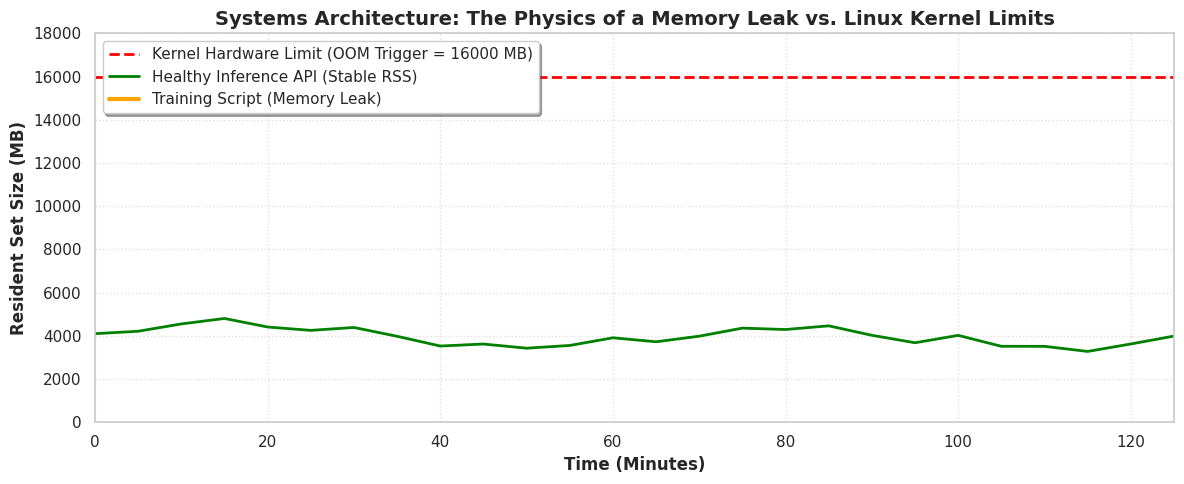

In [3]:
# Simulating a Memory Leak Time-Series
np.random.seed(42)
time_minutes = np.arange(0, 130, 5)

# A healthy process fluctuates (garbage collection works)
healthy_rss = 4000 + 500 * np.sin(time_minutes / 10) + np.random.normal(0, 200, len(time_minutes))

# A leaking process grows linearly/exponentially until the OS limit
leaking_rss = 4000 + (time_minutes ** 1.85) 

# Hardware Limit
hardware_limit = 16000 # 16 GB Max RAM allocation (cgroup limit)

# Calculate the exact point of the SIGKILL
kill_index = np.argmax(leaking_rss > hardware_limit)
leaking_rss[kill_index:] = np.nan # The process ceases to exist mathematically

# Plotting the Telemetry Topology
plt.figure(figsize=(12, 5))

# Plot the safe threshold
plt.axhline(hardware_limit, color='red', linestyle='--', linewidth=2, label=f'Kernel Hardware Limit (OOM Trigger = {hardware_limit} MB)')

# Plot process telemetry
plt.plot(time_minutes, healthy_rss, color='green', linewidth=2, label='Healthy Inference API (Stable RSS)')
plt.plot(time_minutes, leaking_rss, color='orange', linewidth=3, label='Training Script (Memory Leak)')

# Mark the violent SIGKILL event
if kill_index > 0:
    kill_time = time_minutes[kill_index]
    plt.plot(kill_time, hardware_limit, marker='X', markersize=15, color='darkred', markeredgecolor='black')
    plt.annotate(f'SIGKILL (Signal 9)\nProcess Terminated at t={kill_time}m', 
                 xy=(kill_time, hardware_limit), xytext=(kill_time - 30, hardware_limit - 4000),
                 arrowprops=dict(facecolor='darkred', arrowstyle='->', lw=2),
                 fontsize=11, fontweight='bold', color='darkred')

plt.title("Systems Architecture: The Physics of a Memory Leak vs. Linux Kernel Limits", fontsize=14, fontweight='bold')
plt.xlabel("Time (Minutes)", fontsize=12, fontweight='bold')
plt.ylabel("Resident Set Size (MB)", fontsize=12, fontweight='bold')
plt.ylim(0, 18000)
plt.xlim(0, 125)
plt.legend(loc='upper left', frameon=True, shadow=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

*(Insight: The orange line represents a catastrophic code logic error. Because the process was killed instantly at $t=100m$ by the Linux kernel, no Python exceptions were caught, and no data was saved. MLOps systems must monitor `RSS` metrics and alert engineers before the trajectory intersects the red line.)*

## Real-World Use Case or Analogy:

Think of Linux Kernel Resource Management like **A High-End Restaurant Kitchen**:

* **The Server (The Hardware):** The physical kitchen. It has a strict limit of 10 stove burners (CPU) and 50 square feet of counter space (RAM).
* **The Processes (The Chefs):** Every Chef (Process) is assigned a ticket.
* **Healthy Telemetry:** A chef takes up 2 feet of counter space to chop vegetables, finishes the dish, and cleans the counter (Garbage Collection). The counter space (RAM) is freed up for the next chef.
* **The Memory Leak:** A Junior Chef starts preparing a massive banquet. They pull out ingredients and never put them away. Slowly, they consume 10, 20, then 49 square feet of the kitchen counters.
* **The OOM Killer (The Health Inspector):** The kitchen is entirely gridlocked. No one can move. The Head Health Inspector (The Linux Kernel) walks in, looks at a clipboard, identifies the Junior Chef consuming 98% of the space, and mathematically deletes them from the kitchen. The ingredients are dumped in the trash, the space is instantly reclaimed, and the rest of the kitchen survives.

As a Cloud Engineer, your job is not just to write recipes (ML Models); your job is to install cameras (Telemetry via `top`, `ps`) to track the chefs, ensuring they never trigger the wrath of the Health Inspector.